In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp_iv import mp_compliers

In [2]:
# Sommer & Zeger Vitamin A Study Dataset
# Create the dataset from contingency table
data_counts = [
    (0, 0, 0, 74),      # Assigned: No, Received: No, Outcome: Died
    (0, 0, 1, 11514),   # Assigned: No, Received: No, Outcome: Survived
    (1, 0, 0, 34),      # Assigned: Yes, Received: No, Outcome: Died
    (1, 0, 1, 2385),    # Assigned: Yes, Received: No, Outcome: Survived
    (1, 1, 0, 12),      # Assigned: Yes, Received: Yes, Outcome: Died
    (1, 1, 1, 9663)     # Assigned: Yes, Received: Yes, Outcome: Survived
]

Z_data = []
X_data = []
Y_data = []

for z, x, y, count in data_counts:
    Z_data.extend([z] * count)
    X_data.extend([x] * count)
    Y_data.extend([y] * count)

Z_data = np.array(Z_data)
X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"Total observations: {len(Y_data)}")
print(f"Outcome distribution: {np.mean(Y_data):.4f}")
print(f"Treatment (X=1) rate: {np.mean(X_data):.4f}")
print(f"Instrument (Z=1) rate: {np.mean(Z_data):.4f}")

# Summary statistics by instrument assignment
print("\nSummary by Instrument Assignment:")
print(f"  Z=0: P(X=1|Z=0) = {np.mean(X_data[Z_data == 0]):.4f}")
print(f"  Z=1: P(X=1|Z=1) = {np.mean(X_data[Z_data == 1]):.4f}")

Total observations: 23682
Outcome distribution: 0.9949
Treatment (X=1) rate: 0.4085
Instrument (Z=1) rate: 0.5107

Summary by Instrument Assignment:
  Z=0: P(X=1|Z=0) = 0.0000
  Z=1: P(X=1|Z=1) = 0.8000


In [3]:
# Run mp_compliers with Bayesian bootstrap approach
# For binary outcomes with complier identification
B_post = 1000  # Number of posterior samples
T_fwd = 10000

np.random.seed(42)
results_compliers = mp_compliers(Y_data, X_data, Z_data, B_post, T_fwd)


Running Bayesian bootstrap (B=1000)...


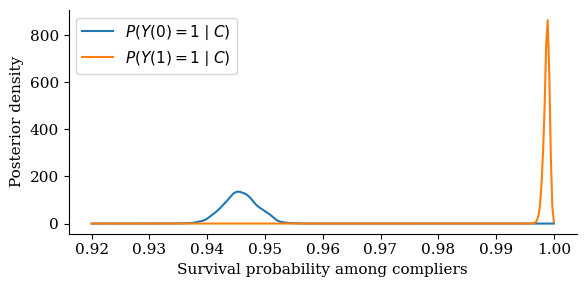

In [7]:
from scipy.stats import gaussian_kde

p_y0_samples = results_compliers['Control']
p_y1_samples = results_compliers['Treatment']

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, ax = plt.subplots(figsize=(6, 3))

for samples, label in [(p_y0_samples, r'$P(Y(0)=1 \mid C)$'), (p_y1_samples, r'$P(Y(1)=1 \mid C)$')]:
    kde = gaussian_kde(samples)
    x = np.linspace(0.92, 1, 300)
    ax.plot(x, kde(x), label=label)

ax.set_xlabel('Survival probability among compliers')
ax.set_ylabel('Posterior density')
ax.legend()
plt.tight_layout()
plt.savefig("Figures/Sommer_Zeger_Results")
plt.show()